In [1]:
from pathlib import Path
import sys
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

load_dotenv(PROJECT_ROOT / ".env")
print(PROJECT_ROOT)

C:\Users\amanm\Desktop\learning\developer-chat-agent


In [2]:
from src.config import parent_store_collection
from src.generation.generator import generate_answer
from src.retrieval.retriever import search_vector_db
from src.caching.semantic_cache import get_semantic_cache, set_semantic_cache
from langchain_groq import ChatGroq
from src.config import OPENAI_MODEL_GROQ, TEMPERATURE, MAX_TOKENS, GROQ_API_KEY



c:\Users\amanm\Desktop\learning\developer-chat-agent\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index 'agenticrag' already exists


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 18575.63it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
from langchain.tools import tool

@tool
def get_documents_for_evaluation(query, namespace: str = "default_namespace"):
    """Search and return information from the vector database."""
    retrieved_chunks = search_vector_db(
        namespace=namespace, 
        query=query, 
        top_k=5
    )
    parent_ids = {chunk.get("parent_id") for chunk in retrieved_chunks if chunk.get("parent_id")}
    
    documents = []
    if parent_ids:
        parent_docs = list(parent_store_collection.find({
            "parent_id": {"$in": list(parent_ids)},
            "namespace": namespace
        }))
        for doc in parent_docs:
            documents.append(doc["text"])
    else:
        for chunk in retrieved_chunks:
            documents.append(chunk["chunk_text"])
            
    return documents

In [4]:
retrieval_tool =  get_documents_for_evaluation

## testing

In [5]:
retrieval_tool.invoke({"query": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?"})


['RAG-ANYTHING: ALL-IN-ONE RAG FRAMEWORK\nRAG-ANYTHING: ALL-IN-ONE RAG FRAMEWORK\nZirui Guo, Xubin Ren, Lingrui Xu, Jiahao Zhang, Chao Huang∗\nThe University of Hong Kong\nzrguo101@hku.hk\nxubinrencs@gmail.com\nchaohuang75@gmail.com\nABSTRACT\nRetrieval-Augmented Generation (RAG) has emerged as a fundamental paradigm\nfor expanding Large Language Models beyond their static training limitations.\nHowever, a critical misalignment exists between current RAG capabilities and\nreal-world information environments. Modern knowledge repositories are inher-\nently multimodal, containing rich combinations of textual content, visual elements,\nstructured tables, and mathematical expressions. Yet existing RAG frameworks are\nlimited to textual content, creating fundamental gaps when processing multimodal\ndocuments. We present RAG-Anything, a unified framework that enables compre-\nhensive knowledge retrieval across all modalities. Our approach reconceptualizes',
 'documents. We present RAG-Anythi

##  Generate query

In [6]:
from langgraph.graph import MessagesState
from langchain.chat_models import init_chat_model

response_model = ChatGroq(
    model=OPENAI_MODEL_GROQ,
    api_key=GROQ_API_KEY,
    temperature=0,
    max_tokens=MAX_TOKENS,
)


def generate_query_or_respond(state: MessagesState):
    """Call the model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply respond to the user.
    """
    response = (
        response_model
        .bind_tools([retrieval_tool]).invoke(state["messages"])
    )
    return {"messages": [response]}

In [7]:
input = {
    "messages": [
        {
            "role": "user",
            "content": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?",
        }
    ]
}
generate_query_or_respond(input)["messages"][-1].pretty_print()

================================== Ai Message ==================================

**RAG‑Anything’s hybrid retrieval**  
RAG‑Anything (Retrieval‑Augmented Generation for “Anything”) is built around the idea that a single type of signal—either pure keyword matching or pure dense‑embedding similarity—never gives the whole picture when we try to pull the right piece of knowledge out of a large, heterogeneous corpus.  
To compensate, the system **fuses two complementary families of signals**:

| **Signal type** | **What it captures** | **Typical source** | **How it is computed** |
|-----------------|----------------------|--------------------|------------------------|
| **Structural signals** | The *layout* and *metadata* of the source material – headings, sections, tables, lists, hyperlinks, citations, document type, timestamps, author tags, etc. | Indexes such as BM25, inverted‑file postings, graph edges, schema annotations, hierarchical IDs (e.g., `doc‑12 → sec‑3 → para‑7`). | • Classic 

## Grade documents

In [11]:
from pydantic import BaseModel, Field
from typing import Literal

GRADE_PROMPT = (
    "You are a grader assessing relevance of a retrieved document to a user question. \n "
    "Here is the retrieved document: \n\n {context} \n\n"
    "Here is the user question: {question} \n"
    "If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n"
    "Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."
)


class GradeDocuments(BaseModel):
    """Grade documents using a binary score for relevance check."""

    binary_score: str = Field(
        description="Relevance score: 'yes' if relevant, or 'no' if not relevant"
    )


grader_model = ChatGroq(
    model=OPENAI_MODEL_GROQ,
    api_key=GROQ_API_KEY,
    temperature=0,
    max_tokens=MAX_TOKENS,
)


def grade_documents(
    state: MessagesState,
) -> Literal["generate_answer", "rewrite_question"]:
    """Determine whether the retrieved documents are relevant to the question."""
    question = state["messages"][0].content
    context = state["messages"][-1].content

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = (
        grader_model
        .with_structured_output(GradeDocuments).invoke(
            [{"role": "user", "content": prompt}]
        )
    )
    score = response.binary_score

    if score == "yes":
        return "generate_answer"
    else:
        return "rewrite_question"

In [15]:
from langchain_core.messages import convert_to_messages
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",  # or your retriever tool
                        "args": {
                            "query": "RAG-Anything cross-modal hybrid retrieval structural knowledge navigation semantic similarity matching"
                        },
                    }
                ],
            },
            {
                "role": "tool",
                "tool_call_id": "1",
                "content": (
                    "RAG-Anything combines structural knowledge navigation and semantic similarity matching. "
                    "Structural navigation uses the knowledge graph to explore entities and relationships, "
                    "capturing multi-hop and cross-modal connections. Semantic similarity uses dense embeddings "
                    "to retrieve relevant content across modalities. These are merged into a unified candidate pool "
                    "and ranked using multi-signal fusion. This is necessary because relying only on structure misses "
                    "semantically relevant content, while relying only on embeddings misses explicit relationships."
                ),
            },
        ]
    )
}

grade_documents(input)

'generate_answer'

##  Rewrite question

In [16]:
from langchain.messages import HumanMessage

REWRITE_PROMPT = (
    "Look at the input and try to reason about the underlying semantic intent / meaning.\n"
    "Here is the initial question:"
    "\n ------- \n"
    "{question}"
    "\n ------- \n"
    "Formulate an improved question:"
)


def rewrite_question(state: MessagesState):
    """Rewrite the original user question."""
    messages = state["messages"]
    question = messages[0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [HumanMessage(content=response.content)]}

In [17]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",
                        "args": {
                            "query": "RAG-Anything hybrid retrieval structural knowledge navigation semantic similarity"
                        },
                    }
                ],
            },
            {
                "role": "tool",
                "content": "meow",
                "tool_call_id": "1",
            },
        ]
    )
}

response = rewrite_question(input)
print(response["messages"][-1].content)

**Improved question**

*In the RAG‑Anything framework, how are structural cues (e.g., document hierarchy, link topology, or metadata) and semantic cues (e.g., vector embeddings, contextual similarity) fused together during the retrieval stage, and what advantages does this combination provide over using either type of signal alone?*


## Generate an answer

In [18]:
GENERATE_PROMPT = (
    "You are an assistant for question-answering tasks. "
    "Use the following pieces of retrieved context to answer the question. "
    "If you don't know the answer, just say that you don't know. "
    "Use three sentences maximum and keep the answer concise.\n"
    "Question: {question} \n"
    "Context: {context}"
)


def generate_answer(state: MessagesState):
    """Generate an answer."""
    question = state["messages"][0].content
    context = state["messages"][-1].content
    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

In [19]:
input = {
    "messages": convert_to_messages(
        [
            {
                "role": "user",
                "content": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?",
            },
            {
                "role": "assistant",
                "content": "",
                "tool_calls": [
                    {
                        "id": "1",
                        "name": "retrieve_blog_posts",  # your retriever tool
                        "args": {
                            "query": "RAG-Anything cross-modal hybrid retrieval structural knowledge navigation semantic similarity matching"
                        },
                    }
                ],
            },
            {
                "role": "tool",
                "content": (
                    "RAG-Anything uses cross-modal hybrid retrieval that combines structural knowledge navigation "
                    "with semantic similarity matching. Structural navigation explores the knowledge graph to find "
                    "entities and relationships across modalities. Semantic similarity uses embeddings to retrieve "
                    "relevant content even without explicit connections. The results are merged and ranked using "
                    "multi-signal fusion. This is necessary because structure captures explicit relationships and "
                    "multi-hop reasoning, while semantic similarity captures implicit relevance."
                ),
                "tool_call_id": "1",
            },
        ]
    )
}

response = generate_answer(input)
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

RAG‑Anything performs cross‑modal hybrid retrieval by first navigating the knowledge graph to collect entities and relationships (structural signal) and then using embedding similarity to fetch content that is relevant even without explicit links (semantic signal). The two result sets are merged and re‑ranked through a multi‑signal fusion step. This combination is needed because structural navigation provides explicit, multi‑hop connections while semantic similarity captures implicit relevance that the graph alone may miss.


## Assemble the graph

In [20]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(MessagesState)

# Define the nodes we will cycle between
workflow.add_node(generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieval_tool]))
workflow.add_node(rewrite_question)
workflow.add_node(generate_answer)

workflow.add_edge(START, "generate_query_or_respond")

# Decide whether to retrieve
workflow.add_conditional_edges(
    "generate_query_or_respond",
    # Assess LLM decision (call `retriever_tool` tool or respond to the user)
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)

# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate_answer", END)
workflow.add_edge("rewrite_question", "generate_query_or_respond")

# Compile
graph = workflow.compile()

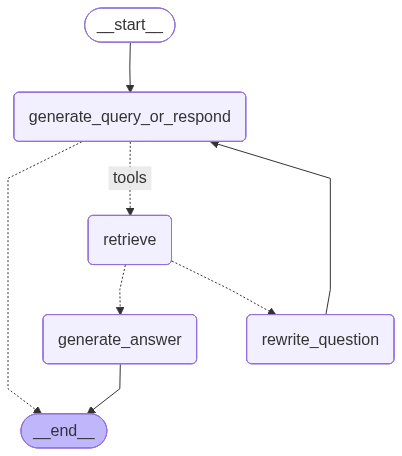

In [21]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

## Run the agentic RAG

In [22]:
for chunk in graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": "How does RAG-Anything combine structural and semantic signals during retrieval, and why is this necessary?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

Update from node generate_query_or_respond
================================== Ai Message ==================================

**RAG‑Anything** (Retrieval‑Augmented Generation “Anything”) is built around a *hybrid* retrieval engine that scores candidate passages with **both structural** and **semantic** signals and then fuses those scores into a single ranking that is fed to the generator.  
Below is a step‑by‑step description of how the two kinds of signals are combined and why that combination is essential for a robust RAG system.

---

## 1. What the two signal families look like

| Signal type | Typical source | What it captures |
|-------------|----------------|------------------|
| **Structural** | • Document hierarchy (chapters → sections → paragraphs) <br>• Metadata (author, date, tags, language, source type) <br>• Hyper‑link / citation graph <br>• Position in a collection (e.g., “most recent version”, “canonical page”) <br>• UI cues (titles, headings, bullet‑list markers) | • Lo